In [12]:
!pip install optuna mlflow -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import subprocess
import joblib
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, classification_report,
                             roc_curve, average_precision_score)
import xgboost as xgb
import optuna
import mlflow
import mlflow.sklearn
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


In [13]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

BASE_PATH = '/content/drive/MyDrive/ML Dataset/'


def reduce_mem_usage(df, verbose=True):
    """
    Downcast numeric columns to the smallest dtype that fits
    their value range, and cast low-cardinality object columns
    to 'category'.  Modifies df in-place and returns it.
    """
    start_mem = df.memory_usage(deep=True).sum() / 1024**2

    for col in df.columns:
        col_type = df[col].dtype

        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()

            if str(col_type).startswith('int'):
                if c_min >= np.iinfo(np.int8).min and c_max <= np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min >= np.iinfo(np.int16).min and c_max <= np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min >= np.iinfo(np.int32).min and c_max <= np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                else:
                    df[col] = df[col].astype(np.int64)
            else:
                # float64 → float32 (sufficient precision for ML features)
                if c_min >= np.finfo(np.float32).min and c_max <= np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            # Cast low-cardinality strings to category (saves ~4x memory)
            if df[col].nunique() / len(df) < 0.5:
                df[col] = df[col].astype('category')

    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    if verbose:
        print(f"Memory: {start_mem:.1f} MB → {end_mem:.1f} MB "
              f"({100*(start_mem-end_mem)/start_mem:.1f}% reduction)")
    return df


print("Loading train data...")
train = pd.read_csv(BASE_PATH + 'train_transaction.csv')
train = reduce_mem_usage(train)

print(f"✅ Shape: {train.shape}")
print(f"\nisFraud distribution:\n{train['isFraud'].value_counts()}")
print(f"\nFraud rate: {train['isFraud'].mean()*100:.2f}%")

Mounted at /content/drive
Loading train data...
Memory: 2062.1 MB → 861.1 MB (58.2% reduction)
✅ Shape: (590540, 394)

isFraud distribution:
isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud rate: 3.50%


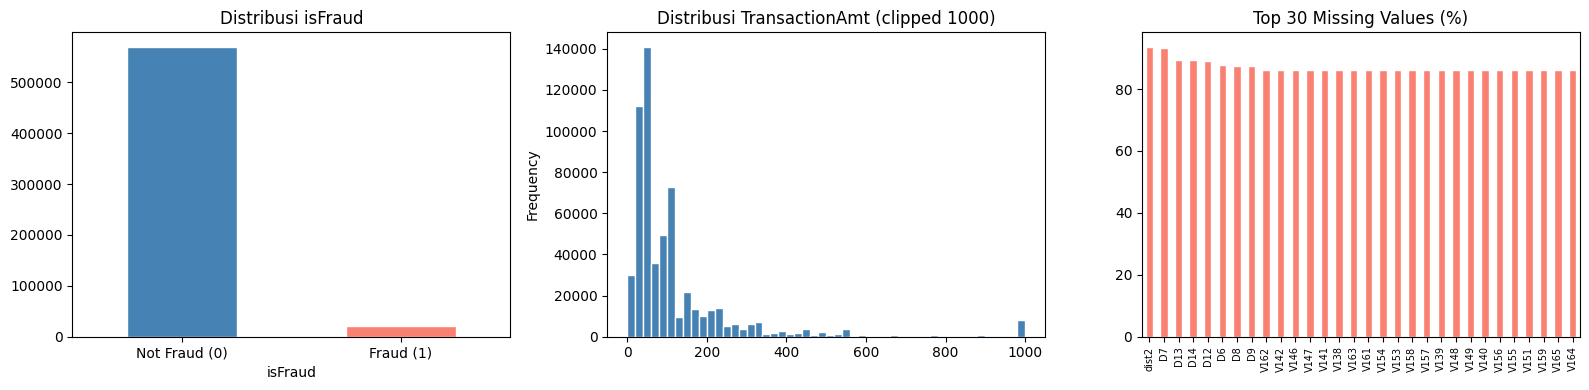


Total kolom dengan missing > 90%: 2
Total kolom dengan missing > 50%: 174


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

train['isFraud'].value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'salmon'], edgecolor='white'
)
axes[0].set_title('Distribusi isFraud')
axes[0].set_xticklabels(['Not Fraud (0)', 'Fraud (1)'], rotation=0)

train['TransactionAmt'].clip(0, 1000).plot(
    kind='hist', bins=50, ax=axes[1], color='steelblue', edgecolor='white'
)
axes[1].set_title('Distribusi TransactionAmt (clipped 1000)')

missing = (train.isnull().mean() * 100).sort_values(ascending=False).head(30)
missing.plot(kind='bar', ax=axes[2], color='salmon', edgecolor='white')
axes[2].set_title('Top 30 Missing Values (%)')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=90, fontsize=7)

plt.tight_layout()
plt.show()

print(f"\nTotal kolom dengan missing > 90%: {(train.isnull().mean() > 0.9).sum()}")
print(f"Total kolom dengan missing > 50%: {(train.isnull().mean() > 0.5).sum()}")

In [15]:
def preprocess(df, is_train=True, encoders=None, drop_cols=None):
    df = df.copy()

    df.drop(columns=['TransactionID'], errors='ignore', inplace=True)

    # Drop columns with missing > 90%
    if drop_cols is None:
        missing_rate = df.isnull().mean()
        drop_cols = missing_rate[missing_rate > 0.9].index.tolist()
        drop_cols = [c for c in drop_cols if c != 'isFraud']
    df.drop(columns=drop_cols, errors='ignore', inplace=True)

    # Feature engineering
    df['TransactionAmt_log'] = np.log1p(df['TransactionAmt'])
    if 'TransactionDT' in df.columns:
        df['hour'] = (df['TransactionDT'] // 3600) % 24
        df['day']  = (df['TransactionDT'] // (3600 * 24)) % 7
        df['week'] = (df['TransactionDT'] // (3600 * 24 * 7)) % 4

    # Separate column types
    # category dtype must be cast back to object for nunique/fillna to work cleanly
    for col in df.select_dtypes(include='category').columns:
        df[col] = df[col].astype(str)

    cat_cols = df.select_dtypes(include='object').columns.tolist()
    num_cols = df.select_dtypes(include=['int8', 'int16', 'int32', 'int64',
                                         'float32', 'float64']).columns.tolist()
    num_cols = [c for c in num_cols if c not in ['isFraud']]

    # Fill missing — direct assignment avoids SettingWithCopyWarning
    for col in num_cols:
        df[col] = df[col].fillna(df[col].median())
    for col in cat_cols:
        df[col] = df[col].fillna('unknown')

    # Label Encoding
    if encoders is None:
        encoders = {}
    for col in cat_cols:
        if col not in encoders:
            encoders[col] = LabelEncoder()
            df[col] = encoders[col].fit_transform(df[col].astype(str))
        else:
            le = encoders[col]
            df[col] = df[col].astype(str).apply(
                lambda x: x if x in le.classes_ else 'unknown'
            )
            df[col] = le.transform(df[col])

    # Re-apply memory reduction after engineering
    df = reduce_mem_usage(df, verbose=False)

    return df, drop_cols, encoders


print("Preprocessing train set...")
train_proc, drop_cols, encoders = preprocess(train, is_train=True)

# Free the raw dataframe immediately — biggest single RAM saving
del train
import gc; gc.collect()

print(f"✅ Shape setelah preprocessing: {train_proc.shape}")
print(f"Kolom yang di-drop (missing >90%): {len(drop_cols)}")

Preprocessing train set...
✅ Shape setelah preprocessing: (590540, 395)
Kolom yang di-drop (missing >90%): 2


In [16]:
EXCLUDE = ['isFraud']
feature_cols = [c for c in train_proc.columns if c not in EXCLUDE]

X = train_proc[feature_cols]
y = train_proc['isFraud']

neg = (y == 0).sum()
pos = (y == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Free the full processed frame — X_train/X_val are views/copies
del train_proc
gc.collect()

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"Fraud rate train: {y_train.mean()*100:.2f}%")
print(f"Fraud rate val  : {y_val.mean()*100:.2f}%")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

scale_pos_weight: 27.58
X_train : (472432, 394)
X_val   : (118108, 394)
Fraud rate train: 3.50%
Fraud rate val  : 3.50%


In [17]:
def evaluate(model_name, y_true, y_pred_proba, threshold=0.5):
    y_pred = (y_pred_proba >= threshold).astype(int)

    roc_auc = roc_auc_score(y_true, y_pred_proba)
    pr_auc  = average_precision_score(y_true, y_pred_proba)

    print(f"\n{'='*45}")
    print(f"  {model_name}")
    print(f"{'='*45}")
    print(f"  ROC-AUC  : {roc_auc:.4f}")
    print(f"  PR-AUC   : {pr_auc:.4f}  ← lebih penting untuk imbalanced data")
    print(f"\n{classification_report(y_true, y_pred, target_names=['Not Fraud','Fraud'])}")

    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f'{model_name} (AUC={roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {model_name}')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {'model': model_name, 'ROC_AUC': roc_auc, 'PR_AUC': pr_auc}

Training Logistic Regression baseline...

  Logistic Regression
  ROC-AUC  : 0.5000
  PR-AUC   : 0.0350  ← lebih penting untuk imbalanced data

              precision    recall  f1-score   support

   Not Fraud       1.00      0.00      0.00    113975
       Fraud       0.03      1.00      0.07      4133

    accuracy                           0.04    118108
   macro avg       0.52      0.50      0.03    118108
weighted avg       0.97      0.04      0.00    118108



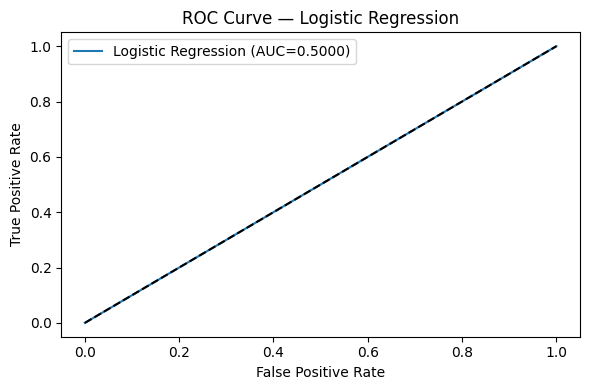

2026/05/15 19:32:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/15 19:32:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Logistic Regression selesai!


In [18]:
results = []
mlflow.set_experiment("FraudDetection_ML")

print("Training Logistic Regression baseline...")

with mlflow.start_run(run_name="LogisticRegression_Baseline"):
    lr = LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    lr.fit(X_train_scaled, y_train)

    # Free scaled arrays right after LR is done — XGBoost uses raw X_train/X_val
    del X_train_scaled, X_val_scaled
    gc.collect()

    y_pred_lr = lr.predict_proba(X_val)[:, 1]
    metrics_lr = evaluate("Logistic Regression", y_val, y_pred_lr)
    results.append(metrics_lr)

    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_metrics({k: v for k, v in metrics_lr.items() if k != 'model'})
    mlflow.sklearn.log_model(lr, "lr_model")

print("✅ Logistic Regression selesai!")

In [19]:
def _has_gpu():
    try:
        result = subprocess.run(['nvidia-smi'], capture_output=True, timeout=5)
        return result.returncode == 0
    except Exception:
        return False

DEVICE      = 'cuda' if _has_gpu() else 'cpu'
TREE_METHOD = 'hist'
print(f"Using device: {DEVICE}")


def objective_xgb(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'        : trial.suggest_int('max_depth', 3, 8),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'gamma'            : trial.suggest_float('gamma', 0, 5),
        'scale_pos_weight' : scale_pos_weight,
        'tree_method'      : TREE_METHOD,
        'device'           : DEVICE,
        'eval_metric'      : 'auc',
        'random_state'     : 42,
    }

    with mlflow.start_run(run_name=f"XGB_trial_{trial.number}", nested=True):
        model = xgb.XGBClassifier(**params)
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        y_pred = model.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)

        mlflow.log_params(params)
        mlflow.log_metric("val_roc_auc", auc)

    # Explicitly delete trial model to reclaim RAM between trials
    del model
    gc.collect()

    return auc


print("Mulai Optuna tuning XGBoost (20 trials)...")
with mlflow.start_run(run_name="XGBoost_Optuna"):
    study_xgb = optuna.create_study(direction='maximize')
    study_xgb.optimize(objective_xgb, n_trials=20, show_progress_bar=True)

    print(f"\n✅ Best ROC-AUC : {study_xgb.best_value:.4f}")
    print(f"Best params    : {study_xgb.best_params}")
    mlflow.log_metric("best_val_roc_auc", study_xgb.best_value)

Using device: cuda
Mulai Optuna tuning XGBoost (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]


✅ Best ROC-AUC : 0.9662
Best params    : {'n_estimators': 411, 'max_depth': 8, 'learning_rate': 0.1634866715350674, 'subsample': 0.6618221815093321, 'colsample_bytree': 0.7725532785557496, 'min_child_weight': 10, 'gamma': 4.128839343541216}


Training final XGBoost model...

  XGBoost (Tuned)
  ROC-AUC  : 0.9662
  PR-AUC   : 0.8051  ← lebih penting untuk imbalanced data

              precision    recall  f1-score   support

   Not Fraud       0.99      0.98      0.99    113975
       Fraud       0.59      0.81      0.68      4133

    accuracy                           0.97    118108
   macro avg       0.79      0.89      0.83    118108
weighted avg       0.98      0.97      0.98    118108



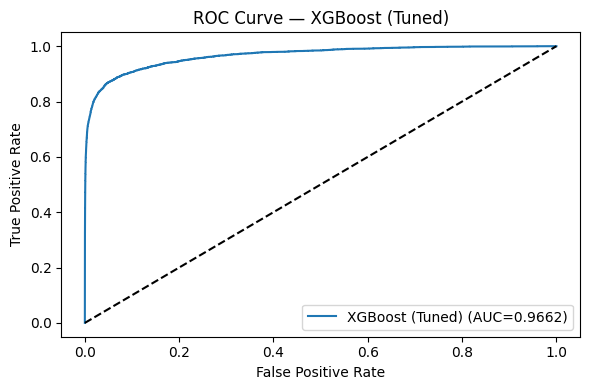

2026/05/15 19:42:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/15 19:42:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


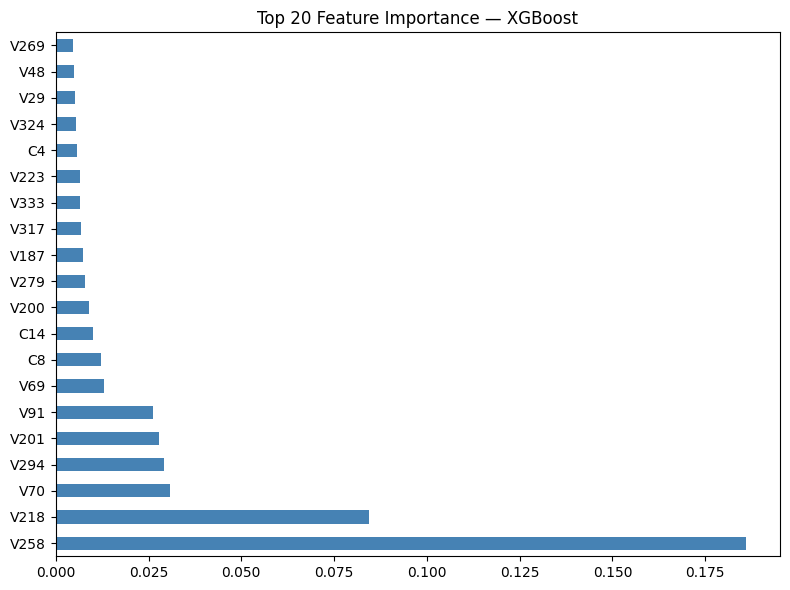

In [20]:
best_params = study_xgb.best_params
best_params.update({
    'scale_pos_weight' : scale_pos_weight,
    'tree_method'      : TREE_METHOD,
    'device'           : DEVICE,
    'eval_metric'      : 'auc',
    'random_state'     : 42
})

print("Training final XGBoost model...")
final_xgb = xgb.XGBClassifier(**best_params)
final_xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

y_pred_xgb = final_xgb.predict_proba(X_val)[:, 1]
metrics_xgb = evaluate("XGBoost (Tuned)", y_val, y_pred_xgb)
results.append(metrics_xgb)

with mlflow.start_run(run_name="XGBoost_Final"):
    mlflow.log_params(best_params)
    mlflow.log_metrics({k: v for k, v in metrics_xgb.items() if k != 'model'})
    mlflow.sklearn.log_model(final_xgb, "xgb_final_model")

feat_imp = pd.Series(final_xgb.feature_importances_, index=feature_cols)
feat_imp.nlargest(20).plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.title('Top 20 Feature Importance — XGBoost')
plt.tight_layout()
plt.show()


=== PERBANDINGAN SEMUA MODEL ===
              model  ROC_AUC   PR_AUC
Logistic Regression 0.500035 0.034996
    XGBoost (Tuned) 0.966226 0.805065


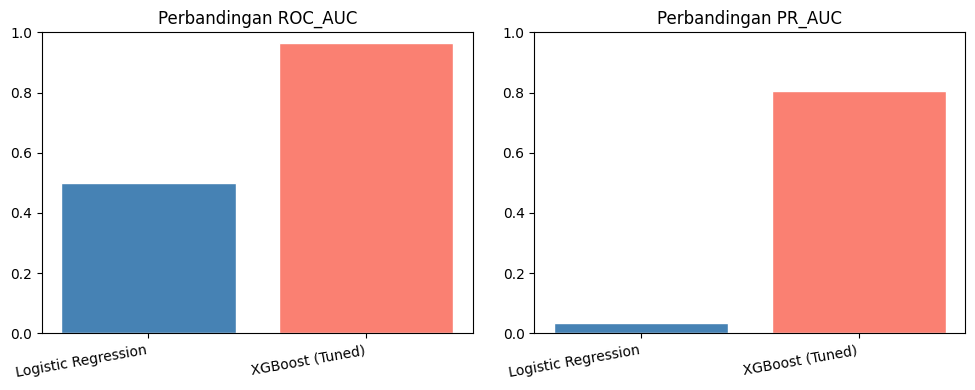

✅ Semua model & artifacts berhasil disimpan ke Drive!


24779

In [21]:
results_df = pd.DataFrame(results)
print("\n=== PERBANDINGAN SEMUA MODEL ===")
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ['steelblue', 'salmon']

for ax, metric in zip(axes, ['ROC_AUC', 'PR_AUC']):
    ax.bar(results_df['model'], results_df[metric],
           color=colors, edgecolor='white')
    ax.set_title(f'Perbandingan {metric}')
    ax.set_ylim(0, 1)
    ax.set_xticklabels(results_df['model'], rotation=10, ha='right')

plt.tight_layout()
plt.show()

SAVE_PATH = '/content/drive/MyDrive/ML Dataset/models_fraud/'
os.makedirs(SAVE_PATH, exist_ok=True)

joblib.dump(lr,        SAVE_PATH + 'lr_model.pkl')
joblib.dump(final_xgb, SAVE_PATH + 'xgb_final.pkl')
joblib.dump(scaler,    SAVE_PATH + 'scaler.pkl')
joblib.dump(encoders,  SAVE_PATH + 'encoders.pkl')
joblib.dump(drop_cols, SAVE_PATH + 'drop_cols.pkl')

print("✅ Semua model & artifacts berhasil disimpan ke Drive!")

# Free training data — no longer needed
del X_train, y_train
gc.collect()

In [22]:
TEST_PATH = BASE_PATH + 'test_transaction.csv'

if os.path.exists(TEST_PATH):
    print("Loading test data...")
    test = pd.read_csv(TEST_PATH)
    test = reduce_mem_usage(test)
    print(f"✅ Test shape: {test.shape}")

    test_ids = test['TransactionID'].copy()

    test_proc, _, _ = preprocess(
        test,
        is_train=False,
        encoders=encoders,
        drop_cols=drop_cols
    )
    del test
    gc.collect()

    test_proc = test_proc.reindex(columns=feature_cols, fill_value=0)
    y_pred_test = final_xgb.predict_proba(test_proc)[:, 1]
    del test_proc
    gc.collect()

    submission = pd.DataFrame({
        'TransactionID': test_ids,
        'isFraud'      : y_pred_test
    })

    SUBMISSION_PATH = SAVE_PATH + 'submission.csv'
    submission.to_csv(SUBMISSION_PATH, index=False)
    print(f"✅ Submission saved to: {SUBMISSION_PATH}")
    print(submission.head(10))
    print(f"\nPredicted fraud rate: {y_pred_test.mean()*100:.2f}%")

else:
    # test_transaction.csv not provided — show validation summary instead
    print("ℹ️  test_transaction.csv not found — skipping inference.")
    print("   Validation set results are used as the final evaluation.\n")

    print("=" * 50)
    print("  FINAL VALIDATION SUMMARY")
    print("=" * 50)
    for r in results:
        print(f"\n  Model   : {r['model']}")
        print(f"  ROC-AUC : {r['ROC_AUC']:.4f}")
        print(f"  PR-AUC  : {r['PR_AUC']:.4f}")
    print("\n" + "=" * 50)

    # Save val predictions from the best model for reference
    val_preds = pd.DataFrame({
        'y_true' : y_val.values,
        'y_pred_proba_xgb' : y_pred_xgb,
        'y_pred_proba_lr'  : y_pred_lr,
    })
    VAL_PRED_PATH = SAVE_PATH + 'val_predictions.csv'
    val_preds.to_csv(VAL_PRED_PATH, index=False)
    print(f"✅ Validation predictions saved to: {VAL_PRED_PATH}")

ℹ️  test_transaction.csv not found — skipping inference.
   Validation set results are used as the final evaluation.

  FINAL VALIDATION SUMMARY

  Model   : Logistic Regression
  ROC-AUC : 0.5000
  PR-AUC  : 0.0350

  Model   : XGBoost (Tuned)
  ROC-AUC : 0.9662
  PR-AUC  : 0.8051

✅ Validation predictions saved to: /content/drive/MyDrive/ML Dataset/models_fraud/val_predictions.csv
